# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [76]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [77]:
coffee_df = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [78]:
coffee_df.head(5)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [156]:
coffee_df.shape


(49745, 18)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [157]:
coffee_df.dtypes

transaction_date           datetime64[us]
transaction_time                      str
customer_id                       float64
quantity                            int64
line_item_amount                  float64
unit_price                        float64
product_group                         str
product_category                      str
product_type                          str
current_wholesale_price           float64
customer_since             datetime64[us]
customer_birth_year               float64
customer_generation                   str
total_wholesale_amount            float64
profit                            float64
profit_ratio                      float64
transaction_day                       str
time_category                         str
dtype: object

> 👉 **Write Your Findings Here**: 
-- -transaction_date and customer_since columns should be date t

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [158]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])
coffee_df.dtypes

transaction_date           datetime64[us]
transaction_time                      str
customer_id                       float64
quantity                            int64
line_item_amount                  float64
unit_price                        float64
product_group                         str
product_category                      str
product_type                          str
current_wholesale_price           float64
customer_since             datetime64[us]
customer_birth_year               float64
customer_generation                   str
total_wholesale_amount            float64
profit                            float64
profit_ratio                      float64
transaction_day                       str
time_category                         str
dtype: object

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [159]:
coffee_df.isnull().mean() *100

transaction_date            0.000000
transaction_time            0.000000
customer_id                50.143733
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.161825
customer_birth_year        50.161825
customer_generation        50.161825
total_wholesale_amount      0.000000
profit                      0.000000
profit_ratio                0.000000
transaction_day             0.000000
time_category               0.000000
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [160]:
# how many duplicates we have
coffee_df.duplicated().sum()


np.int64(0)

In [161]:
# Remove the duplicates and check if the total duplicates is 0 now
coffee_df = coffee_df.drop_duplicates()

coffee_df.duplicated().sum()

np.int64(0)

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [162]:
# unique values in product group
coffee_df['product_group'].unique()
#No inconsistencies found. The categories are clear and organized
#Yes, the spelling is consistent.
#No fixes are needed.

<ArrowStringArray>
['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']
Length: 5, dtype: str

In [163]:
# unique values in product category
coffee_df['product_category'].unique()
#No major inconsistencies found. All categories look correct.
#Yes, the spelling is consistent.
#No fixes are needed.

<ArrowStringArray>
[               'Tea',             'Coffee', 'Drinking Chocolate',
             'Bakery',       'Coffee beans',           'Flavours',
          'Loose Tea', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

In [164]:
# unique values in product type
coffee_df['product_type'].unique()
#capitalized unconsistence

<ArrowStringArray>
[      'Brewed Chai tea', 'Organic brewed coffee',      'Brewed Green tea',
           'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
      'Brewed Black tea',         'Hot chocolate',      'Barista Espresso',
                 'Scone',     'Brewed herbal tea',              'Biscotti',
                'Pastry',         'Organic Beans',         'Regular syrup',
            'Herbal tea',         'Gourmet Beans',             'Black tea',
      'Sugar free syrup',     'House blend Beans',         'Premium Beans',
              'Chai tea',     'Organic Chocolate',    'Drinking Chocolate',
           'Green beans',             'Green tea',        'Espresso Beans',
            'Housewares',              'Clothing']
Length: 29, dtype: str

In [165]:
# unique values in customer_generation
coffee_df['customer_generation'].unique()
#There are missing values (NaN) in this column.
#Yes, the generation names are spelled consistently.
#Only the missing values need to be handled if customer analysis is required.

<ArrowStringArray>
[  'Older Millennials',        'Baby Boomers',               'Gen Z',
               'Gen X', 'Younger Millennials',                   nan]
Length: 6, dtype: str

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [166]:
coffee_df.describe()

,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year,total_wholesale_amount,profit,profit_ratio
count,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792,24792.000000,49745.000000,49745.000000,49745.000000
mean,2019-04-15 01:25:20.257312,4582.647837,1.439481,4.697368,3.384018,1.354957,2018-02-21 06:10:48.209099,1978.248871,1.750993,2.946374,4.460246
min,2019-04-01 00:00:00,1.000000,1.000000,0.800000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000,0.040000,-6.000000,0.666667
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000,0.640000,1.600000,1.780702
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000,1.200000,2.400000,4.000000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000,2.110000,3.920000,5.000000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000,288.000000,72.000000,20.000000
std,NaN,3247.554091,0.543316,4.437372,2.686402,2.204466,NaN,15.088333,3.465079,1.896784,3.659421


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [167]:
coffee_df["total_wholesale_amount"] = (
    coffee_df["current_wholesale_price"] * coffee_df["quantity"]
)
coffee_df.head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [168]:
coffee_df["profit"] = (
    coffee_df["line_item_amount"] - coffee_df["total_wholesale_amount"]
)
coffee_df.head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon


##### 13.❓Find the highest sale price in the dataset.

In [169]:
coffee_df["line_item_amount"].max()


np.float64(360.0)

##### 14.❓Find the largest amount of profit.

In [170]:

coffee_df["profit"].max()

np.float64(72.0)

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [171]:
coffee_df["profit"].mean()


np.float64(2.946374107950548)

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [172]:
coffee_df[coffee_df['line_item_amount'] > coffee_df['line_item_amount'].mean()].shape[0]

19551

##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [173]:
coffee_df["profit_ratio"] = (
    coffee_df["line_item_amount"] /
    coffee_df["total_wholesale_amount"]
)
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday,Evening


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [174]:
(coffee_df['profit_ratio']>=2).sum()

np.int64(37260)

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [175]:
coffee_df['product_category'].str.lower().str.contains('bean').sum()

np.int64(587)

##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [176]:
coffee_df.sort_values('profit',ascending=False)
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday,Evening


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [177]:
coffee_df[coffee_df['profit']<0]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2018-02-10,1975.0,Gen X,18.0,-6.0,0.666667,Sunday,Morning
46268,2019-04-07,10:56:05,5656.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-03-05,1954.0,Baby Boomers,18.0,-6.0,0.666667,Sunday,Morning


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please:
-Some transactions appeared to have a loss, but they were caused by incorrect line_item_amount values rather than real losses.

##### 22.❓Correct the line item amount column with the correct values

In [178]:
coffee_df['line_item_amount'] = coffee_df['unit_price'] * coffee_df['quantity']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday,Evening


##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [179]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday,Evening


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [180]:
coffee_df[coffee_df['profit']<0]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2018-02-10,1975.0,Gen X,18.0,-6.0,0.666667,Sunday,Morning
46268,2019-04-07,10:56:05,5656.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-03-05,1954.0,Baby Boomers,18.0,-6.0,0.666667,Sunday,Morning


##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [181]:
coffee_df['product_group'].value_counts()

product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

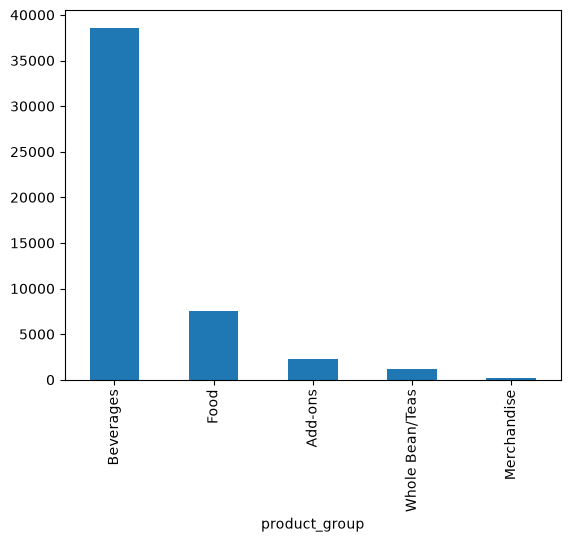

In [182]:
(coffee_df['product_group'].value_counts()).plot(kind = 'bar');

##### 27.❓Can you calculate the median profit for each product type?

In [183]:
coffee_df.groupby('product_type')['profit'].median()

product_type
Barista Espresso          3.40
Biscotti                  1.22
Black tea                 1.79
Brewed Black tea          3.74
Brewed Chai tea           3.74
Brewed Green tea          3.74
Brewed herbal tea         3.74
Chai tea                  1.90
Clothing                 19.04
Drinking Chocolate        2.67
Drip coffee               2.40
Espresso Beans            2.95
Gourmet Beans             4.20
Gourmet brewed coffee     3.20
Green beans               2.00
Green tea                 1.85
Herbal tea                1.79
Hot chocolate             1.74
House blend Beans         3.60
Housewares                9.52
Organic Beans             3.60
Organic Chocolate         1.52
Organic brewed coffee     3.52
Pastry                    1.31
Premium Beans             9.00
Premium brewed coffee     3.92
Regular syrup             1.52
Scone                     1.14
Sugar free syrup          1.52
Name: profit, dtype: float64

##### 28.❓Create a column that shows the transaction_day



In [184]:
coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day_name()

##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [185]:
coffee_df.groupby('transaction_day')['line_item_amount'].sum()
# Yes,  monday is the highest

transaction_day
Friday       32304.55
Monday       39563.74
Saturday     32138.85
Sunday       31014.75
Thursday     31902.82
Tuesday      32371.81
Wednesday    34374.03
Name: line_item_amount, dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

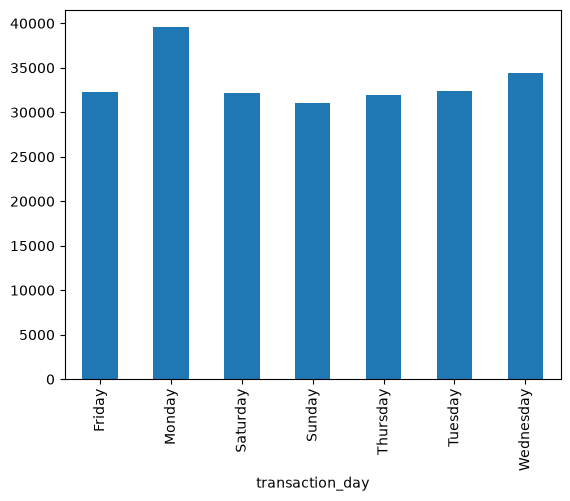

In [186]:
(coffee_df.groupby('transaction_day')['line_item_amount'].sum()).plot(kind = 'bar');


##### Write your findings here please:
#Monday has the highest number of transactions, which may be related to customers returning to work after the weekend.

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [187]:
coffee_df.groupby('customer_generation')['line_item_amount'].sum().sort_values()

customer_generation
Younger Millennials    15414.78
Gen Z                  19716.40
Older Millennials      25166.90
Gen X                  26739.61
Baby Boomers           27295.04
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

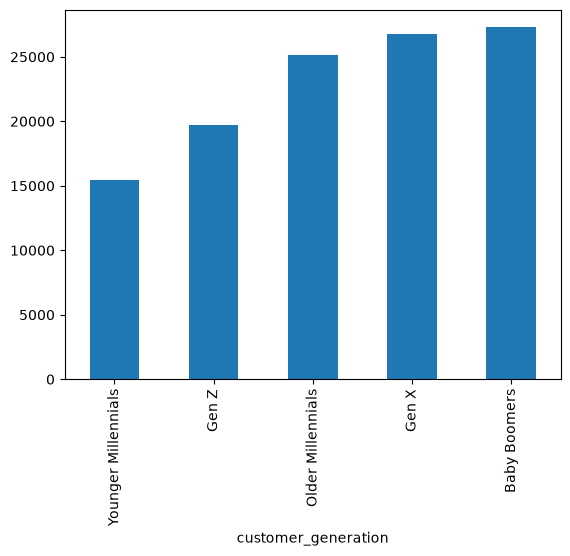

In [188]:
(coffee_df.groupby('customer_generation')['line_item_amount'].sum().sort_values()).plot(kind = 'bar');


##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


In [189]:
coffee_df.head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [190]:

coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending = False).head(5)

product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11829.56
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

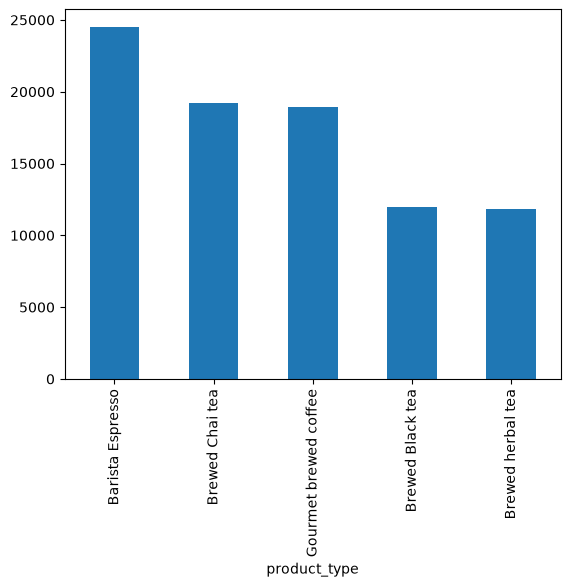

In [191]:

coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending = False).head(5).plot(kind = 'bar');


##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [192]:
coffee_df.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending = False)


customer_generation
Baby Boomers           4.311118
Gen Z                  4.301270
Older Millennials      4.240118
Gen X                  4.229654
Younger Millennials    4.201551
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

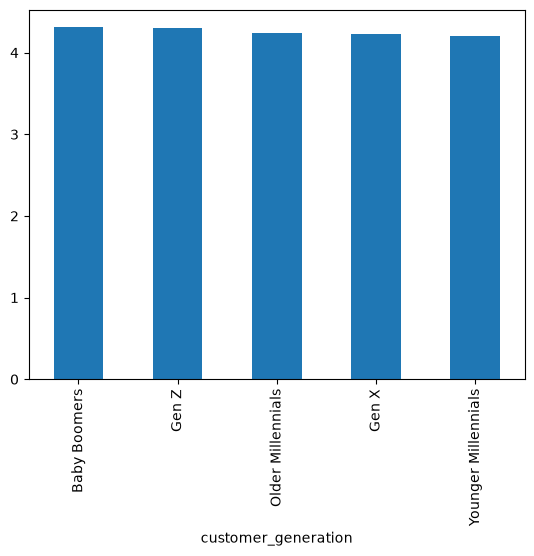

In [193]:
coffee_df.groupby('customer_generation')['profit_ratio'].mean().sort_values(ascending = False).plot(kind = 'bar');





## Part C : Dig Deeper

In [194]:
coffee_df.head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon


In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

In [195]:
# Extracting dates from transaction date
pd.to_datetime(coffee_df['transaction_date'])

0       2019-04-01
1       2019-04-01
2       2019-04-01
3       2019-04-01
4       2019-04-01
           ...    
49889   2019-04-24
49890   2019-04-25
49891   2019-04-25
49892   2019-04-25
49893   2019-04-25
Name: transaction_date, Length: 49745, dtype: datetime64[us]

In [196]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time
def time_category (timings):
    hour = int(str(timings).split(':')[0])
    if hour >=5 and hour < 12:
        return 'Morning'
    elif hour >= 12 and hour < 18:
        return 'Noon'
    elif hour >=18 and hour < 21:
        return 'Evening'
    else:
        return 'Night'
    

# use apply to apply the time category into a new column called time_category
coffee_df['time_category'] = coffee_df['transaction_time'].apply(time_category)
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,Monday,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,Monday,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,Monday,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,Monday,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,Monday,Evening


<Axes: xlabel='transaction_day'>

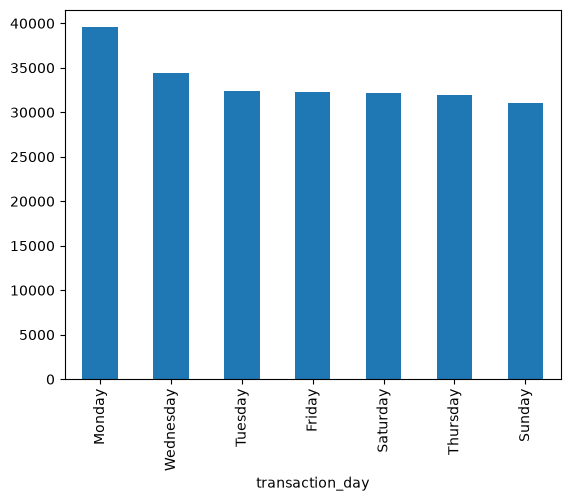

In [197]:
# Are there better or worse days/times in terms of sales?
coffee_df.groupby('transaction_day')['line_item_amount'].sum().sort_values(ascending = False).plot(kind='bar')
# Write your findings

> 👉 **Write Your Findings Here**: 
-- -The days show some differences, with Monday performing better than others, possibly because it is the beginning of the week when productivity tends to be higher.

<Axes: xlabel='time_category'>

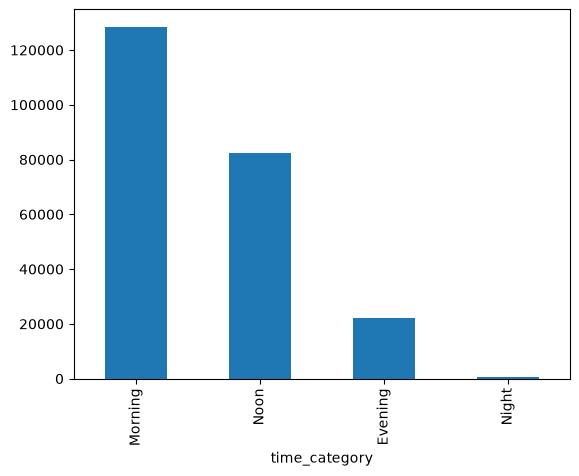

In [198]:
# Are there better or worse days/times in terms of sales?
coffee_df.groupby('time_category')['line_item_amount'].sum().sort_values(ascending = False).plot(kind='bar')

# Write your findings

> 👉 **Write Your Findings Here**: 
-- -The morning is the most popular time for coffee purchases, generating the highest income. This aligns with consumer habits, as many people drink coffee in the morning to begin their day.

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

<Axes: xlabel='customer_generation'>

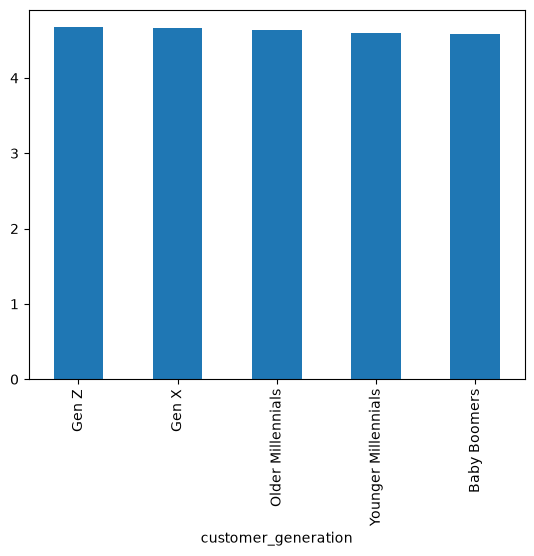

In [199]:
# Does customers’ willingness to pay for Beverages vary by generation?
coffee_df[coffee_df['product_group'] == 'Beverages'].groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending = False).plot(kind='bar')

# Write your findings

> 👉 **Write Your Findings Here**: 
-- -All generations have a similar average spending on beverages, suggesting that their willingness to pay is nearly the same.

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

In [200]:
# Do customers who have been customers longer tend to spend more?
coffee_df.groupby(coffee_df['customer_since'].dt.year)['line_item_amount'].mean().sort_values()


customer_since
2019.0    4.537223
2018.0    4.603922
2017.0    4.640024
Name: line_item_amount, dtype: float64

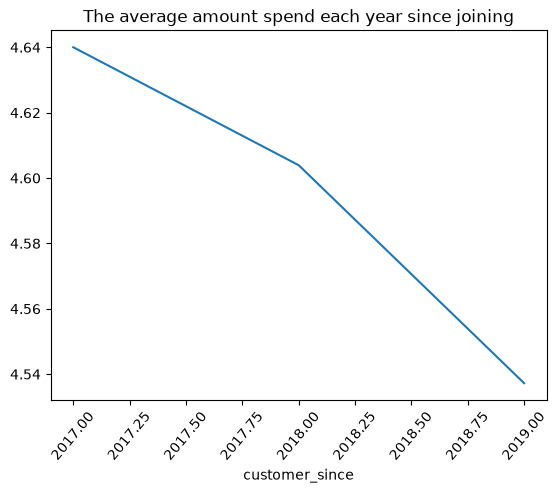

In [201]:
coffee_df.groupby(coffee_df['customer_since'].dt.year)['line_item_amount'].mean().sort_values().plot(kind='line', title = 'The average amount spend each year since joining', rot = 50);


In [202]:
#The results indicate that long-term and older customers tend to spend more, while average spending is lower for customers with shorter relationships with the company.